# Superstore Retail Analytics — Data Visualization

**Continuing from:** `eda_and_data_analysis.ipynb` — that notebook answered the business
questions in tables; this notebook turns those same answers into 16 standalone charts a
stakeholder can read in ten seconds each, plus a one-page executive dashboard.

**Workflow:**

1. **Load the Handoff Tables** — reuse the exact tables exported at the end of the EDA
   notebook, so nothing is recomputed and the numbers are guaranteed to match.
2. **Plot Setup** — one consistent style (colors, fonts, figure size) applied everywhere.
3. **Sales & Profit — the Big Picture** *(charts 1–4)* — where the money comes from, and
   where it leaks.
4. **Time — Is There Seasonality?** *(charts 5–8)* — sales by year, quarter, month, weekday.
5. **Discount & Shipping — Do They Matter?** *(charts 9–11)* — discount vs. profit,
   ship mode vs. speed/profit.
6. **Customers — RFM Segmentation** *(charts 12–14)* — who the best and most at-risk
   customers are.
7. **Products — Winners and Losers** *(chart 15)* — highest profit-per-unit products.
8. **Summary Dashboard** *(chart 16)* — one figure that puts the headline numbers side by
   side.


### Step 1 — Load the Handoff Tables

All tables below were produced and saved in `eda_and_data_analysis.ipynb`. Loading them here — instead of recomputing from raw data — keeps this notebook fast and guarantees the charts match the analysis exactly.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import squarify

DATA_DIR = "handoff_data"

# Row-level table (used only for the correlation heatmap)
df_clean = pd.read_parquet(f"{DATA_DIR}/df_clean.parquet", engine="pyarrow")

# Entity tables
customer_features = pd.read_parquet(f"{DATA_DIR}/customer_features.parquet", engine="pyarrow")
product_features = pd.read_parquet(f"{DATA_DIR}/product_features.parquet", engine="pyarrow")
rfm = pd.read_parquet(f"{DATA_DIR}/rfm.parquet", engine="pyarrow")

# Analysis summary tables
category_margin = pd.read_csv(f"{DATA_DIR}/category_margin.csv")
customer_segment_margin = pd.read_csv(f"{DATA_DIR}/customer_segment_margin.csv")
monthly_sales = pd.read_csv(f"{DATA_DIR}/monthly_sales.csv")
quarter_sales = pd.read_csv(f"{DATA_DIR}/quarter_sales.csv")
year_sales = pd.read_csv(f"{DATA_DIR}/year_sales.csv")
weekday_sales = pd.read_csv(f"{DATA_DIR}/weekday_sales.csv")
orders_by_shipping_days = pd.read_csv(f"{DATA_DIR}/orders_by_shipping_days.csv")
ship_mode_summary = pd.read_csv(f"{DATA_DIR}/ship_mode_summary.csv")
shipping_by_mode = pd.read_csv(f"{DATA_DIR}/shipping_by_mode.csv")
shipping_by_region = pd.read_csv(f"{DATA_DIR}/shipping_by_region.csv")
state_profit = pd.read_csv(f"{DATA_DIR}/state_profit.csv")
rfm_segment_summary = pd.read_csv(f"{DATA_DIR}/rfm_segment_summary.csv")
top_products_profit_per_unit = pd.read_csv(f"{DATA_DIR}/top_products_profit_per_unit.csv")

print("All handoff tables loaded.")


All handoff tables loaded.


### Step 2 — Plot Setup

One palette, one style, applied everywhere so every chart in this notebook looks like it belongs to the same report. Profit-positive values use **teal**, profit-negative values use **coral** — that color coding is used consistently throughout.

In [2]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "#222222",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10.5,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "grid.color": "#dddddd",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
})

POSITIVE = "#2a9d8f"   # teal  -> profit / good
NEGATIVE = "#e76f51"   # coral -> loss / bad
ACCENT = "#264653"     # dark slate -> neutral / sales
ACCENT2 = "#e9c46a"    # sand -> secondary neutral
PALETTE = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]


def money(ax, axis="y"):
    '''Format an axis in $ with thousands separators.'''
    fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)


def annotate_bars(ax, fmt="{:,.0f}", horizontal=False):
    '''Write the value at the end of each bar.'''
    for p in ax.patches:
        if horizontal:
            w = p.get_width()
            ax.annotate(fmt.format(w), (w, p.get_y() + p.get_height() / 2),
                        xytext=(5, 0), textcoords="offset points",
                        va="center", ha="left", fontsize=9)
        else:
            h = p.get_height()
            ax.annotate(fmt.format(h), (p.get_x() + p.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        va="bottom", ha="center", fontsize=9)


### Step 3 — Sales & Profit: the Big Picture

#### Chart 1 — Q1: Which States generate the most Profit, and which generate the biggest loss?

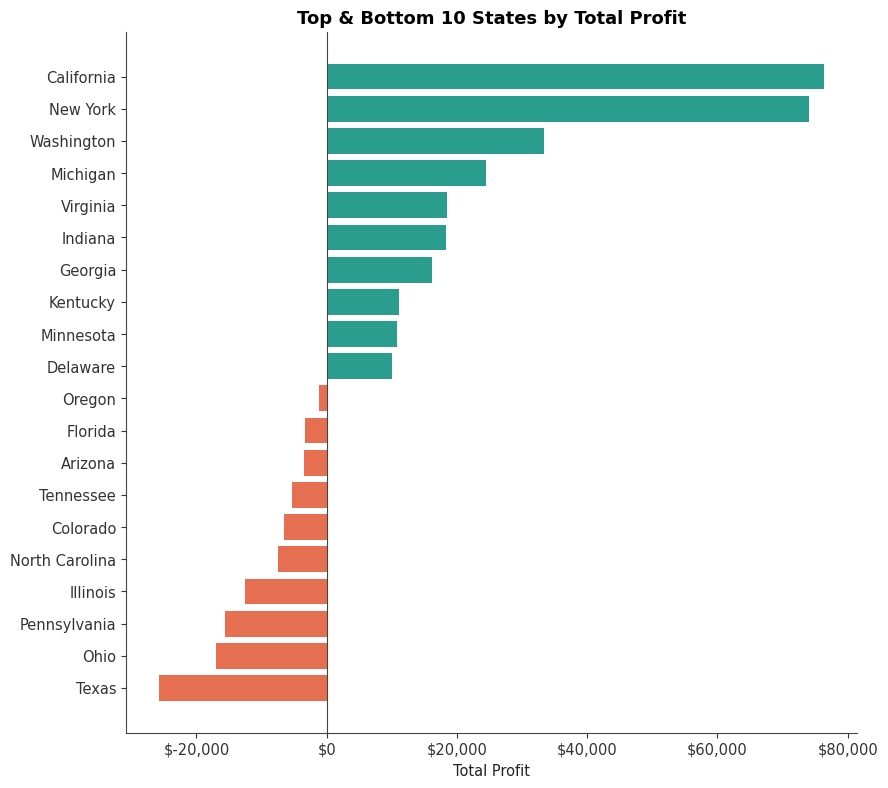

In [3]:
top10 = state_profit.sort_values("Profit", ascending=False).head(10)
bottom10 = state_profit.sort_values("Profit").head(10)
diverging = pd.concat([bottom10, top10]).drop_duplicates(subset="State")
diverging = diverging.sort_values("Profit")

fig, ax = plt.subplots(figsize=(9, 8))
colors = [NEGATIVE if v < 0 else POSITIVE for v in diverging["Profit"]]
ax.barh(diverging["State"], diverging["Profit"], color=colors)
ax.axvline(0, color="#444444", linewidth=0.8)
ax.set_title("Top & Bottom 10 States by Total Profit")
ax.set_xlabel("Total Profit")
money(ax, axis="x")
plt.tight_layout()
plt.show()


**Reading it:** California and New York lead by a wide margin; Texas, Ohio and Pennsylvania are the biggest drags on profit despite generating meaningful sales — worth investigating discounting or product mix in those states.

#### Chart 2 — Q8: Profit Margin by Category

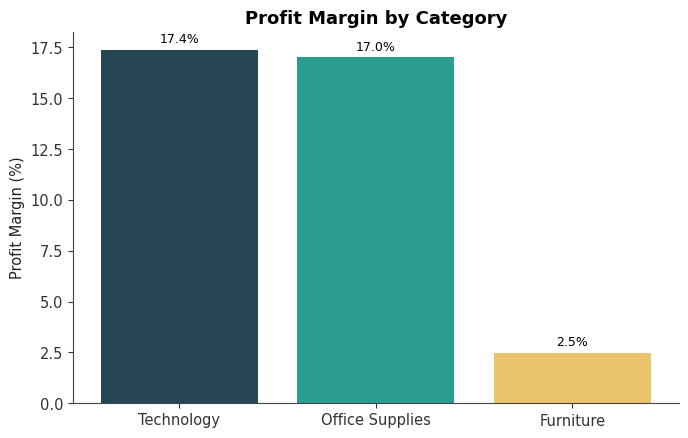

In [4]:
cat = category_margin.sort_values("profit_margin", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(cat["Category"], cat["profit_margin"] * 100, color=PALETTE[:len(cat)])
ax.set_title("Profit Margin by Category")
ax.set_ylabel("Profit Margin (%)")
annotate_bars(ax, fmt="{:.1f}%")
plt.tight_layout()
plt.show()


#### Chart 3 — Q10: Profit Margin by Customer Segment

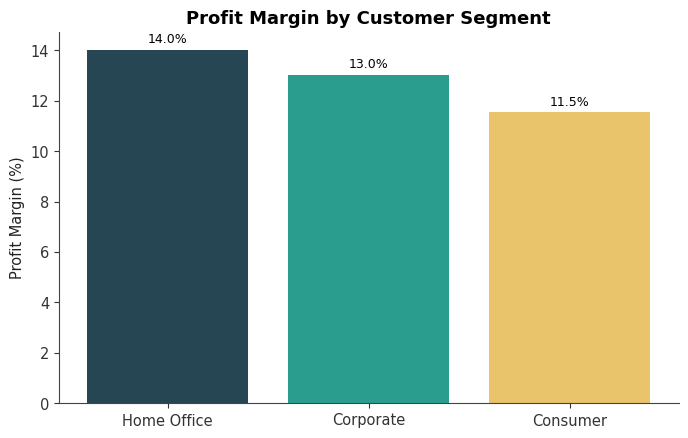

In [5]:
seg = customer_segment_margin.sort_values("profit_margin", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(seg["Segment"], seg["profit_margin"] * 100, color=PALETTE[:len(seg)])
ax.set_title("Profit Margin by Customer Segment")
ax.set_ylabel("Profit Margin (%)")
annotate_bars(ax, fmt="{:.1f}%")
plt.tight_layout()
plt.show()


**Reading it:** Furniture's profit margin (≈2.5%) is far thinner than Technology or Office Supplies (≈17%) — Furniture is generating real sales but barely paying for itself. Home Office customers run the highest margin of the three segments.

#### Chart 4 — Correlation Between Numeric Features

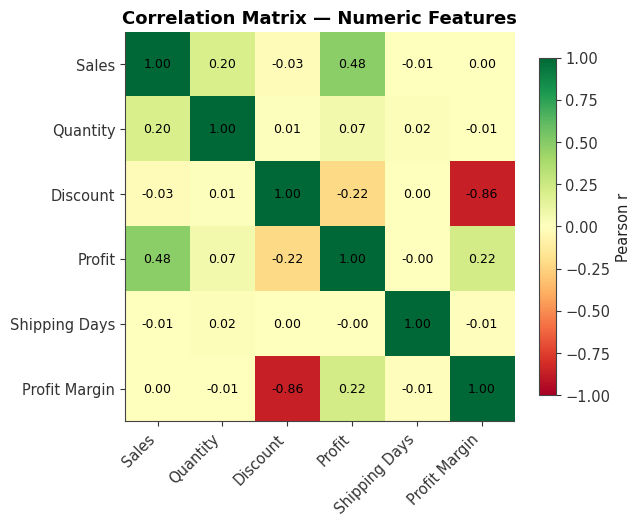

In [6]:
numeric_cols = ["Sales", "Quantity", "Discount", "Profit", "Shipping Days", "Profit Margin"]
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="black", fontsize=9)
ax.set_title("Correlation Matrix — Numeric Features")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
plt.tight_layout()
plt.show()


### Step 4 — Time: Is There Seasonality?

#### Chart 5 — Q6: Total Sales by Year

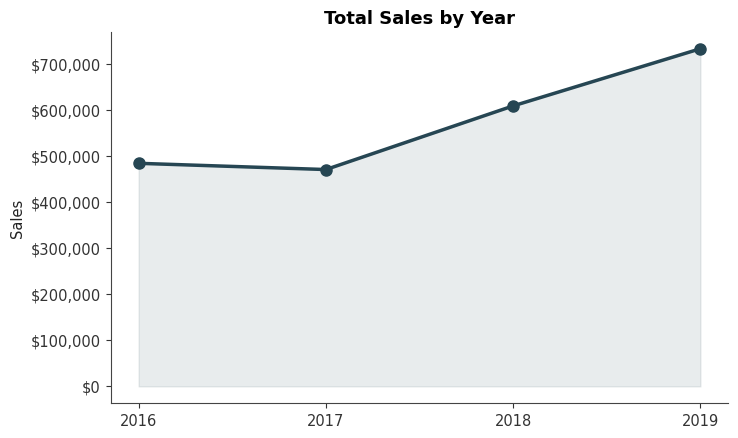

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(year_sales["Order Year"], year_sales["Sales"], marker="o", color=ACCENT, linewidth=2.5, markersize=8)
ax.fill_between(year_sales["Order Year"], year_sales["Sales"], color=ACCENT, alpha=0.1)
ax.set_title("Total Sales by Year")
ax.set_ylabel("Sales")
ax.set_xticks(year_sales["Order Year"])
money(ax)
plt.tight_layout()
plt.show()


#### Chart 6 — Q6: Total Sales by Quarter (All Years Combined)

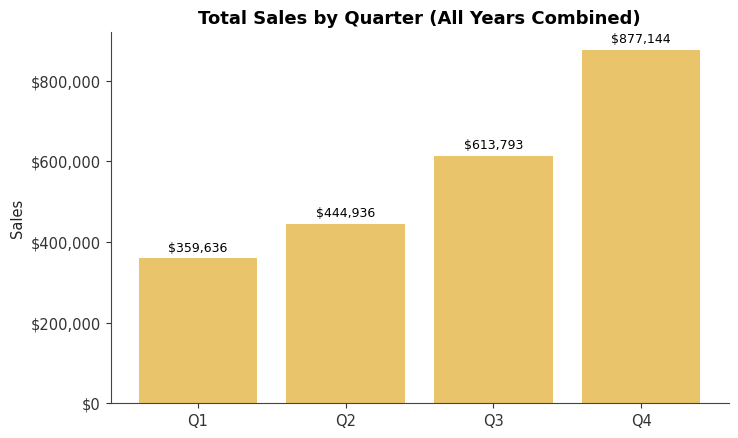

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(quarter_sales["Order Quarter"].astype(str).radd("Q"), quarter_sales["Sales"], color=ACCENT2)
ax.set_title("Total Sales by Quarter (All Years Combined)")
ax.set_ylabel("Sales")
money(ax)
annotate_bars(ax, fmt="${:,.0f}")
plt.tight_layout()
plt.show()


#### Chart 7 — Q4: Total Sales by Month (Seasonality)

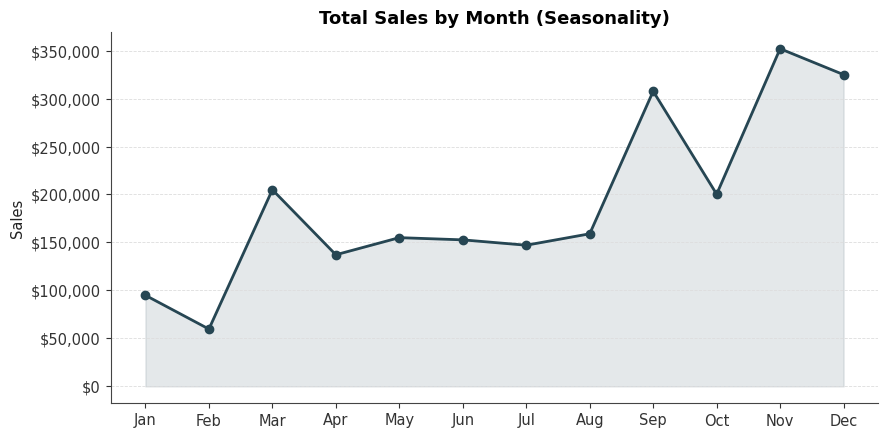

In [9]:
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ms = monthly_sales.sort_values("Order Month")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(month_names, ms["Sales"], marker="o", color=ACCENT, linewidth=2)
ax.fill_between(month_names, ms["Sales"], color=ACCENT, alpha=0.12)
ax.set_title("Total Sales by Month (Seasonality)")
ax.set_ylabel("Sales")
money(ax)
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()


#### Chart 8 — Q4: Total Sales by Weekday (weekend highlighted)

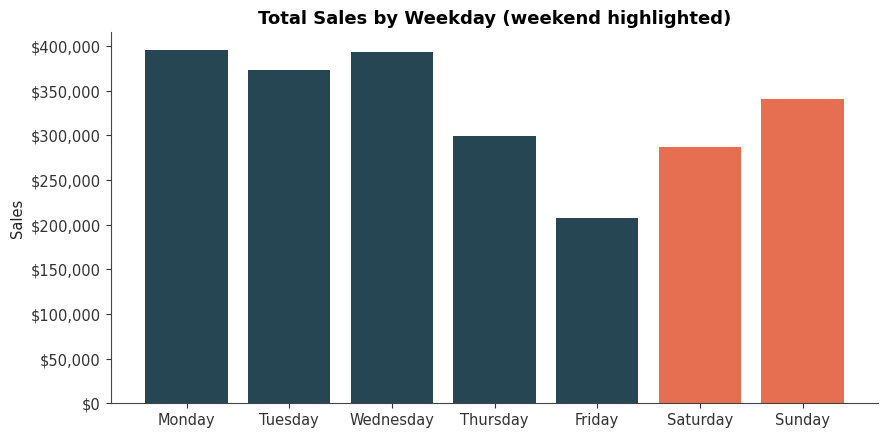

In [10]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
ws = weekday_sales.set_index("Order Weekday").reindex(weekday_order).reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#e76f51" if d in ("Saturday", "Sunday") else ACCENT for d in ws["Order Weekday"]]
ax.bar(ws["Order Weekday"], ws["Sales"], color=colors)
ax.set_title("Total Sales by Weekday (weekend highlighted)")
ax.set_ylabel("Sales")
money(ax)
plt.tight_layout()
plt.show()


**Reading it:** Sales climb steadily through the year and peak hard in Sep–Dec — classic end-of-year / holiday retail pattern. Weekends bring in noticeably less revenue than weekdays, consistent with a B2B-leaning customer base.

### Step 5 — Discount & Shipping: Do They Matter?

#### Chart 9 — Q2: Discount vs. Profit

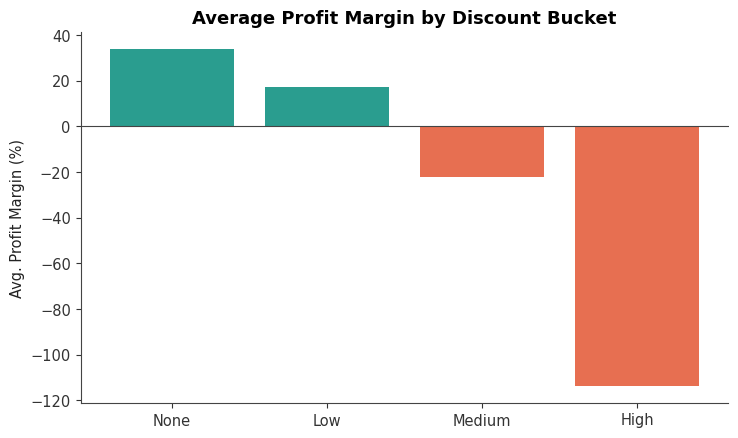

In [11]:
df_bucket = (
    df_clean.groupby("Discount Bucket", observed=True)
    .agg(avg_profit_margin=("Profit Margin", "mean"), orders=("Order ID", "nunique"))
    .reset_index()
)
df_bucket = df_bucket.sort_values("Discount Bucket")
df_bucket["Discount Bucket"] = df_bucket["Discount Bucket"].astype(str)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = [NEGATIVE if v < 0 else POSITIVE for v in df_bucket["avg_profit_margin"]]
ax.bar(df_bucket["Discount Bucket"], df_bucket["avg_profit_margin"], color=colors)
ax.axhline(0, color="#444444", linewidth=0.8)
ax.set_title("Average Profit Margin by Discount Bucket")
ax.set_ylabel("Avg. Profit Margin (%)")
plt.tight_layout()
plt.show()


**Reading it:** Profit margin erodes as the discount bucket increases, turning negative at the high end — deep discounts are, on average, sold at a loss.

#### Chart 10 — Q3: Ship Mode — Speed vs. Avg. Profit

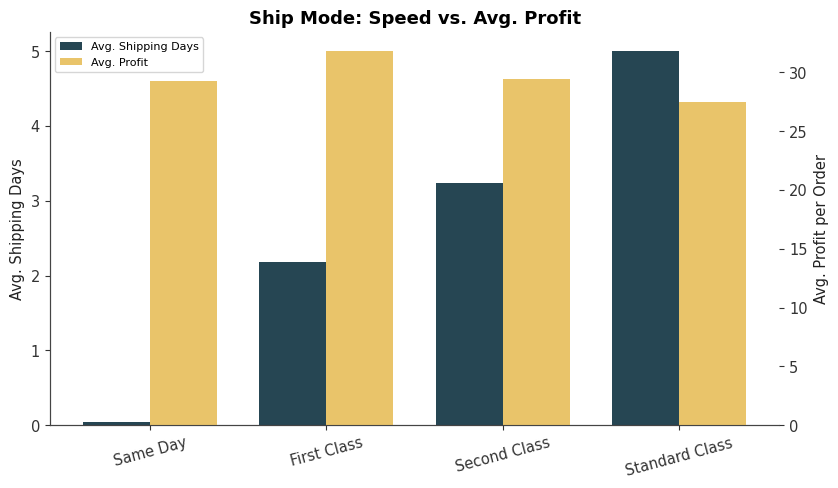

In [12]:
sm = ship_mode_summary.sort_values("avg_shipping_days")
x = np.arange(len(sm))
width = 0.38

fig, ax1 = plt.subplots(figsize=(8.5, 5))
ax2 = ax1.twinx()
ax1.bar(x - width / 2, sm["avg_shipping_days"], width, color=ACCENT, label="Avg. Shipping Days")
ax2.bar(x + width / 2, sm["avg_profit"], width, color=ACCENT2, label="Avg. Profit")
ax1.set_xticks(x)
ax1.set_xticklabels(sm["Ship Mode"], rotation=15)
ax1.set_ylabel("Avg. Shipping Days")
ax2.set_ylabel("Avg. Profit per Order")
ax1.set_title("Ship Mode: Speed vs. Avg. Profit")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


#### Chart 11 — Q7: Shipping Days Range by Ship Mode

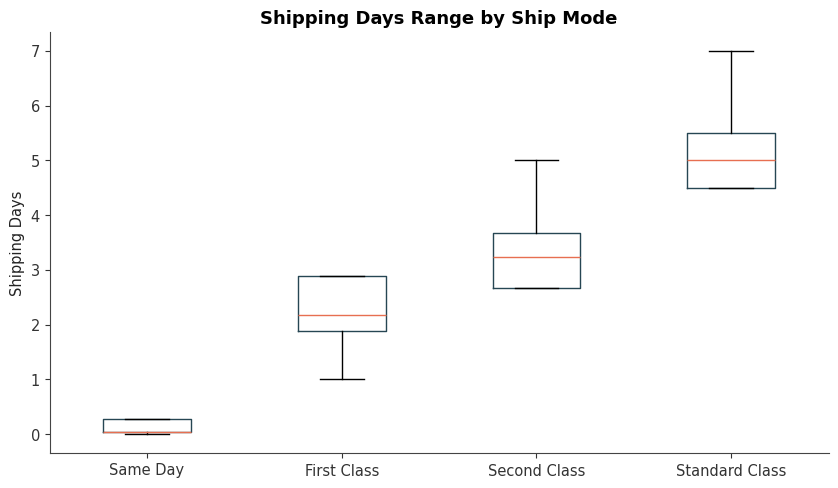

In [13]:
sbm = shipping_by_mode.sort_values("mean")

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.boxplot(
    [[row["min"], row["mean"], row["mean"], row["max"]] for _, row in sbm.iterrows()],
    tick_labels=sbm["Ship Mode"], showfliers=False,
    boxprops=dict(color=ACCENT), medianprops=dict(color=NEGATIVE),
)
ax.set_title("Shipping Days Range by Ship Mode")
ax.set_ylabel("Shipping Days")
plt.tight_layout()
plt.show()


**Reading it:** Ship Mode drives delivery speed dramatically (Same Day ≈0 days vs. Standard Class ≈5 days) but average profit per order is roughly flat across modes — so Ship Mode is mainly an operations lever, not a profitability lever.

### Step 6 — Customers: RFM Segmentation

#### Chart 12 — Q5: Revenue Share by RFM Segment

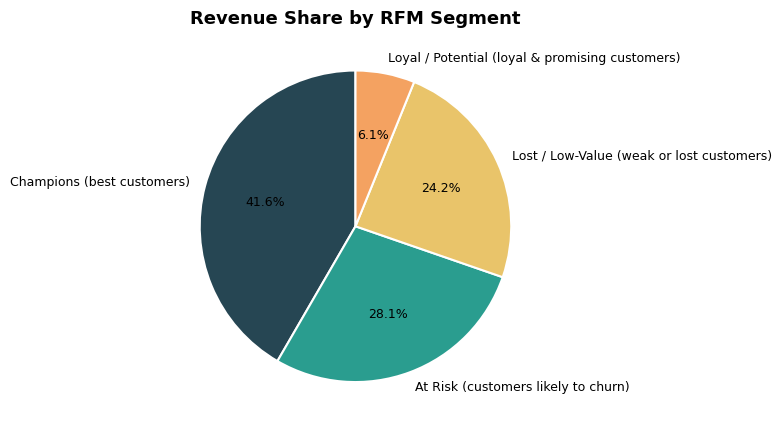

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
seg_colors = PALETTE[:len(rfm_segment_summary)]
ax.pie(
    rfm_segment_summary["revenue_share_%"],
    labels=rfm_segment_summary["Segment"],
    autopct="%1.1f%%",
    colors=seg_colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 9},
)
ax.set_title("Revenue Share by RFM Segment")
plt.tight_layout()
plt.show()


#### Chart 13 — Q5: Customers — Recency vs. Monetary Value

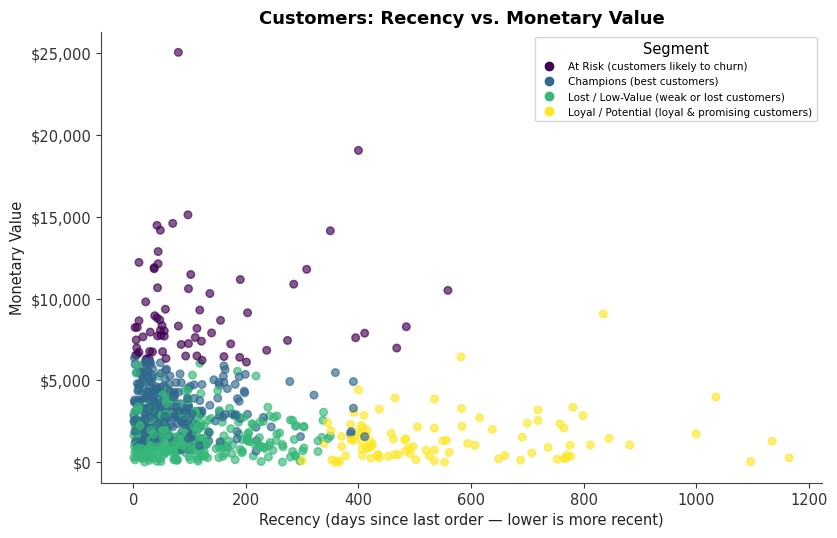

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sc = ax.scatter(
    rfm["Recency"], rfm["Monetary"],
    c=rfm["Segment"].astype("category").cat.codes,
    cmap="viridis", alpha=0.65, s=30,
)
ax.set_title("Customers: Recency vs. Monetary Value")
ax.set_xlabel("Recency (days since last order — lower is more recent)")
ax.set_ylabel("Monetary Value")
money(ax)
seg_cats = rfm["Segment"].astype("category").cat.categories
handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=sc.cmap(sc.norm(i)))
           for i in range(len(seg_cats))]
ax.legend(handles, seg_cats, fontsize=7.5, loc="upper right", title="Segment")
plt.tight_layout()
plt.show()


#### Chart 14 — Customer Base Composition as a Treemap

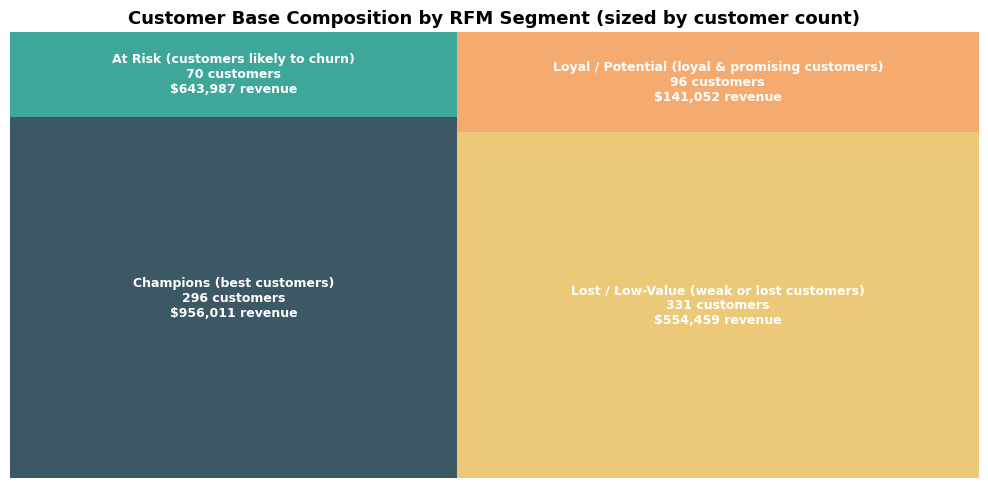

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sizes = rfm_segment_summary["customers"]
labels = [
    f"{seg}\n{n} customers\n${rev:,.0f} revenue"
    for seg, n, rev in zip(rfm_segment_summary["Segment"], sizes, rfm_segment_summary["revenue"])
]
squarify.plot(sizes=sizes, label=labels, color=PALETTE[:len(sizes)],
              alpha=0.9, ax=ax, text_kwargs={"fontsize": 9, "color": "white", "weight": "bold"})
ax.set_title("Customer Base Composition by RFM Segment (sized by customer count)")
ax.axis("off")
plt.tight_layout()
plt.show()


**Reading it:** *Champions* make up well under half of the customer base but drive the single largest share of revenue — the retention priority. *At Risk* customers still carry meaningful revenue, making them the best target for a win-back campaign before that value is lost.

### Step 7 — Products: Winners and Losers

#### Chart 15 — Q11: Top 15 Products by Profit per Unit

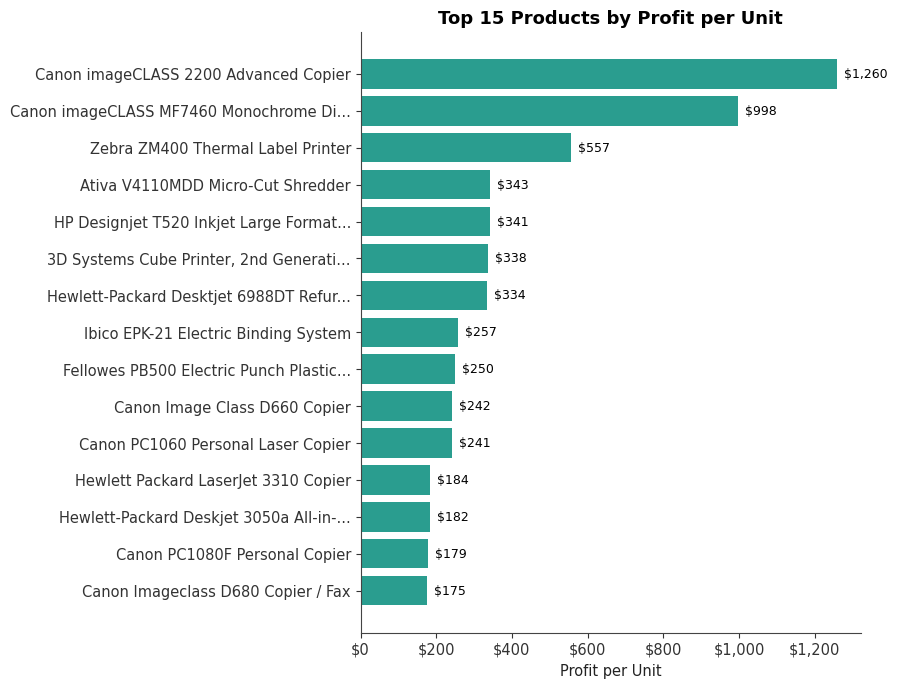

In [17]:
top15 = top_products_profit_per_unit.sort_values("Profit per Unit", ascending=False).head(15)
top15 = top15.sort_values("Profit per Unit")

fig, ax = plt.subplots(figsize=(9, 7))
labels = [n if len(n) <= 40 else n[:37] + "..." for n in top15["Product Name"]]
ax.barh(labels, top15["Profit per Unit"], color=POSITIVE)
ax.set_title("Top 15 Products by Profit per Unit")
ax.set_xlabel("Profit per Unit")
money(ax, axis="x")
annotate_bars(ax, fmt="${:,.0f}", horizontal=True)
plt.tight_layout()
plt.show()


**Reading it:** Profit-per-unit is dominated by a handful of Technology products (copiers, machines) — high-value, low-volume items that punch far above their sales share and are worth protecting on inventory and pricing.

### Step 8 — Summary Dashboard

#### Chart 16 — Executive Summary

One figure with the headline numbers side by side — the slide to show if there's only room for one chart.

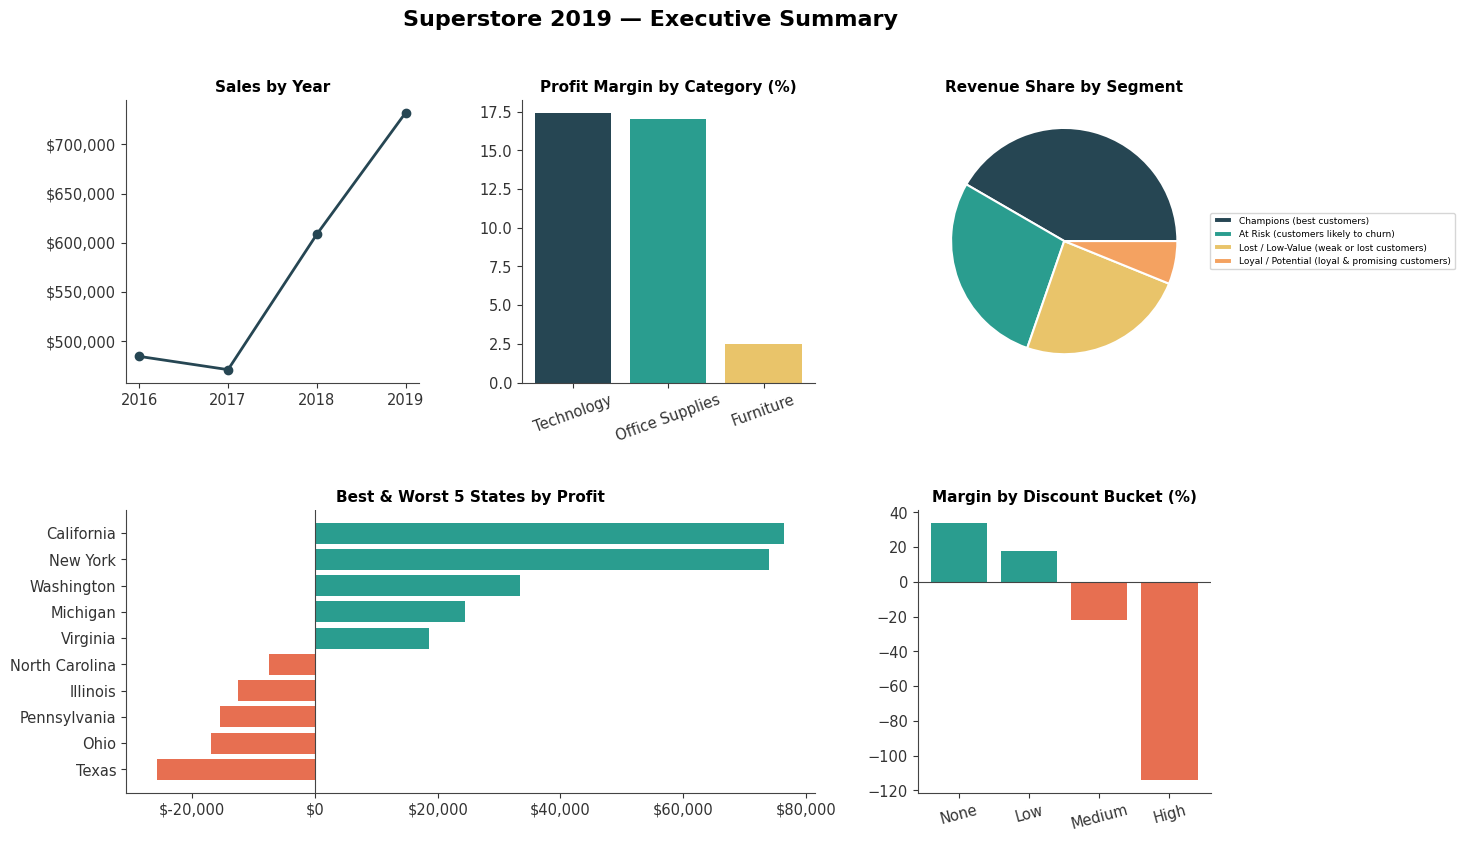

Dashboard saved to superstore_dashboard.png


In [18]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# 1. Yearly sales trend
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(year_sales["Order Year"], year_sales["Sales"], marker="o", color=ACCENT, linewidth=2)
ax1.set_title("Sales by Year", fontsize=11)
money(ax1)

# 2. Category profit margin
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(cat["Category"], cat["profit_margin"] * 100, color=PALETTE[:len(cat)])
ax2.set_title("Profit Margin by Category (%)", fontsize=11)
ax2.tick_params(axis="x", rotation=20)

# 3. Revenue share by RFM segment
ax3 = fig.add_subplot(gs[0, 2])
ax3.pie(rfm_segment_summary["revenue_share_%"], labels=None, colors=PALETTE[:len(rfm_segment_summary)],
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax3.set_title("Revenue Share by Segment", fontsize=11)
ax3.legend(rfm_segment_summary["Segment"], loc="center left", bbox_to_anchor=(1, 0.5), fontsize=6.5)

# 4. Top/bottom 5 states by profit
ax4 = fig.add_subplot(gs[1, :2])
div5 = pd.concat([
    state_profit.sort_values("Profit").head(5),
    state_profit.sort_values("Profit", ascending=False).head(5),
]).drop_duplicates(subset="State").sort_values("Profit")
colors4 = [NEGATIVE if v < 0 else POSITIVE for v in div5["Profit"]]
ax4.barh(div5["State"], div5["Profit"], color=colors4)
ax4.axvline(0, color="#444444", linewidth=0.8)
ax4.set_title("Best & Worst 5 States by Profit", fontsize=11)
money(ax4, axis="x")

# 5. Discount bucket vs margin
ax5 = fig.add_subplot(gs[1, 2])
colors5 = [NEGATIVE if v < 0 else POSITIVE for v in df_bucket["avg_profit_margin"]]
ax5.bar(df_bucket["Discount Bucket"], df_bucket["avg_profit_margin"], color=colors5)
ax5.axhline(0, color="#444444", linewidth=0.8)
ax5.set_title("Margin by Discount Bucket (%)", fontsize=11)
ax5.tick_params(axis="x", rotation=15)

fig.suptitle("Superstore 2019 — Executive Summary", fontsize=16, fontweight="bold")
plt.savefig("superstore_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved to superstore_dashboard.png")


### Key Takeaways

- **Geography:** Profit is concentrated in California and New York; Texas, Ohio and Pennsylvania post the largest losses despite solid sales — a discounting or product-mix problem in those states.
- **Discounting:** Profit margin declines steadily as discount depth increases and turns negative at the highest discount bucket.
- **Seasonality:** Sales rise through the year and peak in Sep–Dec; weekends underperform weekdays.
- **Shipping:** Ship Mode strongly controls delivery speed but barely moves average profit — treat it as an operations dial, not a profitability lever.
- **Category / Segment margin:** Furniture's margin (≈2.5%) lags far behind Technology and Office Supplies (≈17%); Home Office is the most profitable customer segment.
- **Customers:** Champions are a small group that drives the largest share of revenue; At Risk customers hold enough remaining value to justify a targeted win-back campaign.
- **Products:** Profit-per-unit is dominated by a small set of high-value Technology products, not high-volume Office Supplies items.